In [ ]:
import numpy as np
from tqdm import tqdm
import math

def transformMatrix(A):
    return np.vstack([np.outer(r, r).flatten() for r in A])


def caratheodory(P, u,rank, dtype='float16'):

    while 1:
        n = np.count_nonzero(u)
        d = P.shape[1]
        u_non_zero = np.nonzero(u)

        if n <= rank + 1:
            # return u
            # return selected_points and corresponding non zero weights
            selected_points = P[u_non_zero]
            selected_weights = u[u_non_zero]
            selected_weights = selected_weights / np.sum(selected_weights)
            return selected_points, selected_weights

        A = P[u_non_zero]
        reduced_vec = np.outer(A[0], np.ones(A.shape[0]-1, dtype = dtype))
        A = A[1:].T - reduced_vec
        # print("Starting SVD")
        _, _, V = np.linalg.svd(A, full_matrices=True)
        # print("Calculated SVD")

        v=V[-1]
        v = np.insert(v, [0],   -1 * np.sum(v))

        idx_good_alpha = np.nonzero(v > 0)
        alpha = np.min(u[u_non_zero][idx_good_alpha]/v[idx_good_alpha])

        w = np.zeros(u.shape[0] , dtype = dtype)
        tmp_w = u[u_non_zero] - alpha * v
        tmp_w[np.argmin(tmp_w)] = 0.0
        w[u_non_zero] = tmp_w
        w[u_non_zero][np.argmin(w[u_non_zero] )] = 0
        u = w




def streaming_caratheodory(P, w, d):
    
    n = len(P)
    selected_points = P[:d+1]
    selected_weights = w[:d+1]
    
    for i in tqdm(range(d+1, n)):

        selected_points = np.vstack((selected_points, P[i]))
        selected_weights = np.append(selected_weights, w[i])
        w1=selected_weights.sum()
        selected_weights = selected_weights / w1
        # print("Rank in streaming caratheodory", d)
        # Apply Caratheodory's theorem to reduce the set to d+1 points
        selected_points, selected_weights = caratheodory(np.array(selected_points), np.array(selected_weights),d)
        selected_weights = selected_weights* w1
    selected_points, selected_weights = caratheodory(np.array(selected_points), np.array(selected_weights), d)
    return selected_points, selected_weights


def fast_caratheodory_set(P, w, k, rank):
    n, d = P.shape
    # print(n, d)
    # Step 1: Remove zero-weight points
    # n= len(P)
    mask = w > 0
    P = P[mask]
    w = w[mask]
    
    # Step 2: Base case
    if len(P) <= rank + 1:
        return P, w

    # Step 4: Partition into k clusters
    partitions = []
    weights_partitions = []
    # k=root(e)*d
    k = int(np.ceil(np.sqrt(math.e) * d))
    if k > len(P):
        k = len(P)
        
    chunk_size = int(np.ceil(len(P) / k))
    if chunk_size<=d+1:
        # print("chunk_size", chunk_size, d+1)
        # print("Remaining points", len(P))
        # print("Rank", rank)
        return streaming_caratheodory(P, w, rank)
    
    for i in range(0, len(P), chunk_size):
        partitions.append(P[i:i + chunk_size])
        weights_partitions.append(w[i:i + chunk_size])

    # Step 5-7: Compute weighted means and cluster weights
    means = []
    new_weights = []
    for Pi, wi in zip(partitions, weights_partitions):
        total_w = np.sum(wi)
        mean = np.dot(wi, Pi) / total_w
        means.append(mean)
        new_weights.append(total_w)
    means = np.array(means)
    new_weights = np.array(new_weights)

    # Step 8: Carathéodory   n cluster means

    reduced_means, reduced_weights = caratheodory(means, new_weights, P.shape[1])

    # Step 9-11: Collect and reweight points from chosen clusters
    C = []
    final_weights = []

    for mean_point, weight in zip(reduced_means, reduced_weights):
        idx = np.where(np.all(means == mean_point, axis=1))[0][0]
        Pi = partitions[idx]
        wi = weights_partitions[idx]
        total_w = np.sum(wi)
        for p, wp in zip(Pi, wi):
            C.append(p)
            final_weights.append(weight * wp / total_w)

    C = np.array(C)
    final_weights = np.array(final_weights)

    # Step 12: Recursive call
    return fast_caratheodory_set(C, final_weights, k, rank)



In [6]:
import pandas as pd

# df= pd.read_csv("household_power_consumption.txt", sep=";", low_memory=False, na_values=["nan", "?"])
df=pd.read_csv("sgemm_product.csv", sep=",", low_memory=False, na_values=["nan", "?"])
df = df.dropna()
df.head(4)

,MWG,NWG,KWG,MDIMC,NDIMC,MDIMA,NDIMB,KWI,VWM,VWN,STRM,STRN,SA,SB,Run1 (ms),Run2 (ms),Run3 (ms),Run4 (ms)
0,16,16,16,8,8,8,8,2,1,1,0,0,0,0,115.26,115.87,118.55,115.80
1,16,16,16,8,8,8,8,2,1,1,0,0,0,1,78.13,78.25,79.25,79.19
2,16,16,16,8,8,8,8,2,1,1,0,0,1,0,79.84,80.69,80.76,80.97
3,16,16,16,8,8,8,8,2,1,1,0,0,1,1,84.32,89.90,86.75,85.58


In [7]:
# Compute mean of the last 4 Run columns and store in a new 'target' column
df['target'] = df[['Run1 (ms)', 'Run2 (ms)', 'Run3 (ms)', 'Run4 (ms)']].mean(axis=1)

# Drop the original run columns
df.drop(columns=['Run1 (ms)', 'Run2 (ms)', 'Run3 (ms)', 'Run4 (ms)', "STRM", "STRN", "SA", "SB"], inplace=True)

# Resulting DataFrame
print(df.head())

   MWG  NWG  KWG  MDIMC  NDIMC  MDIMA  NDIMB  KWI  VWM  VWN    target
0   16   16   16      8      8      8      8    2    1    1  116.3700
1   16   16   16      8      8      8      8    2    1    1   78.7050
2   16   16   16      8      8      8      8    2    1    1   80.5650
3   16   16   16      8      8      8      8    2    1    1   86.6375
4   16   16   16      8      8      8      8    2    1    1  118.6625


In [8]:
# create X and Y matrix using df
X = df.drop(columns=['target']).values
y= df['target'].values

In [ ]:
from sklearn.model_selection import train_test_split

# Perform truncated SVD on the original data
def truncated_svd(A, k):
    # Compute the SVD of A
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    
    # Keep only the top k singular values and corresponding vectors
    U_k = U[:, :k]
    S_k = S[:k]
    Vt_k = Vt[:k, :]
    
    return U_k, S_k, Vt_k

# Apply truncated SVD to reduce the dimensionality of A
k = 10 # Number of dimensions to keep
X, S1, V1 = truncated_svd(X, k)

# normalize X
X= (X - X.mean()) / X.std()


In [11]:
import numpy as np
X=np.array(X)
y=np.array(y)
# split into 70:30 ratio

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# print(x_train.shape)

In [12]:
# X.shape


In [13]:
def transformMatrix(A):
    return np.vstack([np.outer(r, r).flatten() for r in A])

In [ ]:
import numpy as np

# Make a matrix of the type [X y \n sqrt(lambda)*I 0]
def makeMatrix(X, y, lmbda):
    n = X.shape[0]  # Number of samples
    d = X.shape[1]  # Number of features
    
    # Initialize the matrix A
    A = np.zeros((n + d, d + 1))
    
    # Fill the top part with X and y
    A[:n, :d] = X
    A[:n, d] = y
    # Add the regularization term (sqrt(lambda) * I)
    A[n:, :d] = np.sqrt(lmbda) * np.eye(d)
    return A


In [15]:
import time
def fit_model(P, A_or, y_or):
    X=P[:,:-1]
    y=P[:,-1]
    start = time.perf_counter()
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    # print(w.shape)
    # print(A_or.shape)
    end = time.perf_counter()
    y_pred = A_or @ w
    rmse = np.sqrt(np.mean((y_or - y_pred) ** 2))
    return w, rmse,( end-start)*1000



In [16]:
x_test.shape
# y_test.shape
# U1.shape

(72480, 10)

In [19]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(169120, 10) (169120,)
(72480, 10) (72480,)


In [20]:
n_non_regularization_points = []
coreset_construction_timings=[]
kernalization_timings=[]
# A=A
for lambda_ in  [  1_00_00, 1_00_0,3_00, 1_00, 1_0, 1, 0.1, 0.01, 0.001, 0.0001, 0.00001]:
    A = makeMatrix(x_train, y_train, lambda_)
    st1=time.perf_counter()
    M1=transformMatrix(A)
    en1=time.perf_counter()
    kernalization_timings.append((en1-st1)*1000)
    u1=np.ones(M1.shape[0])/len(M1)
    d=M1.shape[1]

    rank = np.linalg.matrix_rank(M1)
    print("Rank of M1:", rank)
    # print(M1[0])
    # print(M1[-1])
    # print(M1[-2])
    st2=time.perf_counter()
    c, u= streaming_caratheodory(M1, u1, rank)
    en2=time.perf_counter()
    coreset_construction_timings.append((en2-st2)*1000)

    # print(c)
    # count the number of regularization points in the coreset
    num_regularization_points = np.count_nonzero(c[:, -1])
    print("Number of regularization points in the coreset:", num_regularization_points)
    # print the RMSE on both coreset and original data


    coreset_points, coreset_weights=c, u
    u=u/sum(u)
    final_points=[]
    for i in range(len(coreset_points)):
        m1=coreset_points[i].reshape(A.shape[1] ,A.shape[1]) 
        x1=np.array([np.sqrt(x) for x in np.diag(m1)])*np.sqrt(coreset_weights[i])
        final_points.append(x1)
    final_points=np.array(final_points)

    w1, rmse_coreset, time_coreset = fit_model(final_points, x_test, y_test)

    # calculate the loss and model fit time for the original data
    w2, rmse_original, time_original = fit_model(A, x_test, y_test)
    # print a comparision
    print("Lambda:", lambda_)
    print("Time taken for coreset model fitting:", time_coreset)
    print("RMSE for coreset data:", rmse_coreset)
    print("RMSE for original data:", rmse_original)
    print("Time taken for model fit on original data:", time_original)
    

    # print("Coreset Construction time:", (en2-st2)*1000)
    print("Kernalization time:", (en1-st1)*1000)
    # print("RMSE for Coreset data:", rmse)
    n_non_regularization_points.append(num_regularization_points)
# print("Caratheodory weights:")
# print(w)
# prisnt("Caratheodory weights sum:")
# print(np.sum(w)) 
# print("Caratheodory weights non-zero:")
# print(np.count_nonzero(w))

Rank of M1: 66


100%|██████████| 169063/169063 [01:32<00:00, 1818.08it/s]


Number of regularization points in the coreset: 58
Lambda: 10000
Time taken for coreset model fitting: 0.057249999827035936
RMSE for coreset data: 684.1723099634241
RMSE for original data: 287.4537286686455
Time taken for model fit on original data: 4.099958000097104
Kernalization time: 482.4024580002515
Rank of M1: 66


100%|██████████| 169063/169063 [01:31<00:00, 1845.33it/s]


Number of regularization points in the coreset: 62
Lambda: 1000
Time taken for coreset model fitting: 0.0328749997606792
RMSE for coreset data: 914.0652282871773
RMSE for original data: 286.7234882299864
Time taken for model fit on original data: 2.9397919997791178
Kernalization time: 441.2537080002039
Rank of M1: 66


...

Number of regularization points in the coreset: 67
Lambda: 0.001
Time taken for coreset model fitting: 0.02670799995030393
RMSE for coreset data: 909.6751372333642
RMSE for original data: 286.7194691529459
Time taken for model fit on original data: 3.131999999823165
Kernalization time: 459.1148750000684
Rank of M1: 66


100%|██████████| 169063/169063 [01:45<00:00, 1604.67it/s]


Number of regularization points in the coreset: 67
Lambda: 0.0001
Time taken for coreset model fitting: 0.048207999952865066
RMSE for coreset data: 909.6751372333642
RMSE for original data: 286.7194691573357
Time taken for model fit on original data: 4.516750000220782
Kernalization time: 446.11670799986314
Rank of M1: 66


100%|██████████| 169063/169063 [01:30<00:00, 1860.89it/s]

Number of regularization points in the coreset: 67
Lambda: 1e-05
Time taken for coreset model fitting: 0.03033399980267859
RMSE for coreset data: 909.6751372333642
RMSE for original data: 286.7194691577747
Time taken for model fit on original data: 3.0987500003902824
Kernalization time: 521.6117079999094


In [35]:
# print a table of lambda values vs coreset construction time and kernalization time and print the avergae

import pandas as pd

lambda_values = [  1_00_00, 1_00_0,3_00, 1_00, 1_0, 1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
df = pd.DataFrame({
    'Lambda': lambda_values,
    'Coreset Construction Time (ms)': coreset_construction_timings,
    'Kernalization Time (ms)': kernalization_timings,
    'Number of Regularization Points': n_non_regularization_points
})

print(df)

# print the average of coreset construction time and kernalization time
average_coreset_time = np.mean(coreset_construction_timings)
average_kernalization_time = np.mean(kernalization_timings)
print("Average Coreset Construction Time (ms):", average_coreset_time)
print("Average Kernalization Time (ms):", average_kernalization_time)

         Lambda  Coreset Construction Time (ms)  Kernalization Time (ms)  \
0   10000.00000                    93003.867542               482.402458   
1    1000.00000                    91617.204792               441.253708   
2     300.00000                    95274.317792               404.173041   
3     100.00000                    93363.925708               420.402500   
4      10.00000                    91450.050375               422.621167   
5       1.00000                    92248.691000               465.396125   
6       0.10000                    93934.215250               427.897375   
7       0.01000                    92609.258167               407.332458   
8       0.00100                    93841.834375               459.114875   
9       0.00010                   105357.789666               446.116708   
10      0.00001                    90851.187917               521.611708   

    Number of Regularization Points  
0                                58  
1          

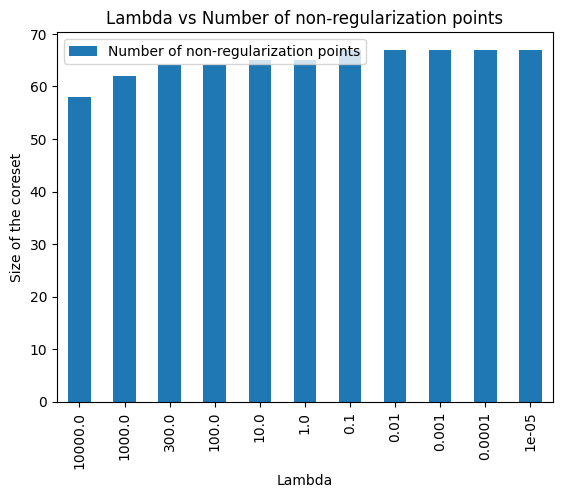

             Number of non-regularization points
Lambda                                          
10000.00000                                   58
1000.00000                                    62
300.00000                                     64
100.00000                                     64
10.00000                                      65
1.00000                                       65
0.10000                                       67
0.01000                                       67
0.00100                                       67
0.00010                                       67
0.00001                                       67


In [24]:
# create a table for Lambda vs the number of non-regularization points in the coreset
import pandas as pd
import matplotlib.pyplot as plt

lambdas=  [  1_00_00, 1_00_0,3_00, 1_00, 1_0, 1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
df = pd.DataFrame({'Lambda': lambdas, 'Number of non-regularization points': n_non_regularization_points})
df = df.set_index('Lambda')
df.plot(kind='bar')
plt.xlabel('Lambda')
plt.ylabel('Size of the coreset')
plt.title('Lambda vs Number of non-regularization points')
plt.show()
print(df)


In [25]:
# multiple root(u) with c
for i in range(len(c)):
    c[i] = c[i] * np.sqrt(u[i])
print(c)

[[ 1.65728211e-01 -1.03773129e-02  2.22272089e-01 ... -1.19880372e+02
   1.16377901e+02  3.72108233e+04]
 [ 1.97496538e-01 -8.95355011e-03  1.32604995e-01 ...  3.13010426e+02
  -7.05310253e+01  2.36323303e+05]
 [ 5.99695110e-02  4.70288214e-02 -2.05084744e-01 ...  5.43917843e+00
   1.58582552e+01  9.15909182e+02]
 ...
 [ 4.04684334e-02 -3.32240797e-03 -1.01709355e-01 ...  2.47564057e+00
  -4.42641087e+00  3.21190099e+02]
 [ 1.32263053e-03  3.07843681e-03 -3.51141945e-04 ... -6.95082969e-02
   1.19002513e-03  1.82413029e+01]
 [ 1.33624197e-02 -1.43169040e-02 -9.46535545e-03 ...  6.01965852e-02
  -6.31085103e-02  9.57724735e+00]]


In [26]:
coreset_points, coreset_weights=c, u
final_points=[]
for i in range(len(coreset_points)):
    m1=coreset_points[i].reshape(A.shape[1] ,A.shape[1]) 
    x1=np.array([np.sqrt(x) for x in np.diag(m1)])*np.sqrt(coreset_weights[i])
    final_points.append(x1)
final_points=np.array(final_points)

In [27]:
import time
def fit_model(P, A_or, y_or):
    X=P[:,:-1]
    y=P[:,-1]
    start = time.perf_counter()
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    print(w.shape)
    print(A_or.shape)
    end = time.perf_counter()
    y_pred = A_or @ w
    rmse = np.sqrt(np.mean((y_or - y_pred) ** 2))
    return w, rmse,( end-start)*1000



In [28]:
w1, rmse1, time1= fit_model(final_points, x_test, y_test)
print("RMSE for Coreset data:", rmse1)
print("Time taken for coreset data:", time1)


(10,)
(72480, 10)
RMSE for Coreset data: 819.9505314266981
Time taken for coreset data: 0.11912499985555769


In [29]:
original_data = np.concatenate((x_train, y_train.reshape(-1, 1)), axis=1)
w1, rmse1, time1= fit_model(original_data, x_test, y_test)
print("RMSE for Original  data:", rmse1)
print("Time taken for Original data:", time1)


(10,)
(72480, 10)
RMSE for Original  data: 286.7194691578235
Time taken for Original data: 3.3522499998071


In [30]:
def check_corset(original, Coreset):
    original=original/np.sqrt(len(original))
    CoresetT=np.array(Coreset).T
    CTC=np.dot(CoresetT,Coreset)
    OTO=np.dot(original.T,original)
    flag=True
    for i in range(len(OTO)):
        for j in range(len(OTO[0])):
            if abs(OTO[i][j]-CTC[i][j])>0.0001:
                flag=False
                break
    return flag

print("Check Coreset:")
print(check_corset(original_data, final_points))

Check Coreset:
False


In [38]:
import random
import numpy as np
import time
import pandas as pd  # Ensure pandas is imported for creating the table

# Define the mapping of size to lambda
size_toLambda = {
    58: 10_000, 
    62: 1_000,
    64: 300,
    64: 100,
    65: 10,
    65: 1,
    67: 0.1,
    67: 0.01,
    67: 0.001,
    67: 0.0001,
    67: 0.00001
}

# Perform random sampling for sizes between 57 and 67
all_rmse = []
all_time = []
all_lambdas = []

for i in range(1):  # Repeat the process if needed
    rmse_list = []
    time_list = []
    lambda_list = []

    for size in range(57, 68):  # Sizes between 57 and 67
        t1 = time.perf_counter()
        
        # Skip sizes not in the mapping
        if size not in size_toLambda:
            continue
        
        # Get the corresponding lambda
        lambda_ = size_toLambda[size]

        # Create the matrix A using the given lambda
        A = makeMatrix(x_train, y_train, lambda_)
        
        # Randomly sample indices
        sampled_indices = random.sample(range(A.shape[0]), size)
        sampled_data = A[sampled_indices]
        
        t2 = time.perf_counter()
        
        # Fit the model using the sampled data
        w2, rmse2, time2 = fit_model(sampled_data, x_test, y_test)
    
        # Store RMSE, time, and lambda
        rmse_list.append(rmse2)
        time_list.append(time2 + (t2 - t1) * 1000)  # Include sampling time in total time
        lambda_list.append(lambda_)
        
        print(f"Lambda: {lambda_}, Size: {size}, RMSE: {rmse2}, Time: {time2 + (t2 - t1) * 1000} ms")
    
    all_rmse.append(rmse_list)
    all_time.append(time_list)
    all_lambdas.append(lambda_list)

# Calculate averages
average_times = np.mean(all_time, axis=0)
average_rmse = np.mean(all_rmse, axis=0)
average_lambdas = np.mean(all_lambdas, axis=0)

# Create a DataFrame to display the results
df1 = pd.DataFrame({
    'Size': list(size_toLambda.keys()),
    'Lambda': list(size_toLambda.values()),
    'RMSE': average_rmse,
    'Time (ms)': average_times
})

# Print the table
print(df1)

# Print overall averages
print("\nAverage RMSE:", average_rmse)
print("Average Time (ms):", average_times)

(10,)
(72480, 10)
Lambda: 10000, Size: 58, RMSE: 322.1006652566103, Time: 2.411834000668023 ms
(10,)
(72480, 10)
Lambda: 1000, Size: 62, RMSE: 304.7502267759354, Time: 2.5384579985257005 ms
(10,)
(72480, 10)
Lambda: 100, Size: 64, RMSE: 299.59659859653414, Time: 1.6927090018725721 ms
(10,)
(72480, 10)
Lambda: 1, Size: 65, RMSE: 330.24192070622183, Time: 2.772709000055329 ms
(10,)
(72480, 10)
Lambda: 1e-05, Size: 67, RMSE: 356.3278233541743, Time: 1.6656670013617259 ms
   Size       Lambda        RMSE  Time (ms)
0    58  10000.00000  322.100665   2.411834
1    62   1000.00000  304.750227   2.538458
2    64    100.00000  299.596599   1.692709
3    65      1.00000  330.241921   2.772709
4    67      0.00001  356.327823   1.665667

Average RMSE: [322.10066526 304.75022678 299.5965986  330.24192071 356.32782335]
Average Time (ms): [2.411834 2.538458 1.692709 2.772709 1.665667]


In [40]:
import numpy as np
import time
import pandas as pd
from sklearn.utils.extmath import randomized_svd
from sklearn.utils import check_random_state

# Leverage score sampling function
def leverage_score_sampling(A, n_samples, random_state=None):
    rng = check_random_state(random_state)
    U, _, _ = randomized_svd(A, n_components=min(A.shape)-1, random_state=rng)
    leverage_scores = np.sum(U**2, axis=1)
    leverage_scores /= np.sum(leverage_scores)
    sampled_indices = rng.choice(A.shape[0], size=n_samples, replace=False, p=leverage_scores)
    return sampled_indices


# Define the mapping of size to lambda
size_toLambda = {
    58: 10_000, 
    62: 1_000,
    64: 300,
    64: 100,
    65: 10,
    65: 1,
    67: 0.1,
    67: 0.01,
    67: 0.001,
    67: 0.0001,
    67: 0.00001
}

# Set up
runs = 5
sizes = list(range(57, 68))
rmse_dict = {size: [] for size in sizes}
time_dict = {size: [] for size in sizes}

# Run 5 iterations
for run in range(runs):
    print(f"\nRun {run + 1}")
    for size in sizes:
        # Skip sizes not in the mapping
        if size not in size_toLambda:
            continue
        lambda_ = size_toLambda[size]
        A = makeMatrix(x_train, y_train, lambda_)
        t1 = time.perf_counter()
        sampled_indices = leverage_score_sampling(A, size, random_state=run + size)
        sampled_data = A[sampled_indices]
        t2 = time.perf_counter()

        # Fit the model using the sampled data
        w, rmse, t_fit = fit_model(sampled_data, x_test, y_test)
        
        total_time = t_fit + (t2 - t1) * 1000
        rmse_dict[size].append(rmse)
        time_dict[size].append(total_time)
        
        print(f"Size: {size}, Lambda: {lambda_}, RMSE: {rmse:.6f}, Time: {total_time:.4f} ms")

# Create a table of average RMSE, time, and lambda for each size
df2 = pd.DataFrame({
    'Size': sizes,
    'Lambda': [size_toLambda[size] if size in size_toLambda else None for size in sizes],
    'Avg RMSE': [np.mean(rmse_dict[size]) for size in sizes],
    'Avg Time (ms)': [np.mean(time_dict[size]) for size in sizes]
})

print("\n=== AVERAGE RESULTS ===")
print(df2)

# Print averages in a formatted way
print("\n=== AVERAGE RESULTS OVER 5 RUNS ===")
print(f"{'Size':<6}{'Lambda':<10}{'Avg RMSE':<12}{'Avg Time (ms)':<15}")
for size in sizes:
    if size not in size_toLambda:
        continue
    avg_rmse = np.mean(rmse_dict[size])
    avg_time = np.mean(time_dict[size])
    lambda_ = size_toLambda[size]
    print(f"{size:<6}{lambda_:<10}{avg_rmse:<12.6f}{avg_time:<15.4f}")


Run 1
(10,)
(72480, 10)
Size: 58, Lambda: 10000, RMSE: 339.338450, Time: 207.7501 ms
(10,)
(72480, 10)
Size: 62, Lambda: 1000, RMSE: 458.645424, Time: 96.3357 ms
(10,)
(72480, 10)
Size: 64, Lambda: 100, RMSE: 400.419575, Time: 107.5929 ms
(10,)
(72480, 10)
Size: 65, Lambda: 1, RMSE: 504.824472, Time: 100.5012 ms
(10,)
(72480, 10)
Size: 67, Lambda: 1e-05, RMSE: 390.407976, Time: 103.8474 ms

Run 2
(10,)
(72480, 10)
Size: 58, Lambda: 10000, RMSE: 503.848549, Time: 100.9303 ms
(10,)
(72480, 10)
Size: 62, Lambda: 1000, RMSE: 314.971874, Time: 103.2520 ms
(10,)
(72480, 10)
Size: 64, Lambda: 100, RMSE: 459.081941, Time: 108.5339 ms
(10,)
(72480, 10)
Size: 65, Lambda: 1, RMSE: 358.210325, Time: 107.6151 ms
(10,)
(72480, 10)
Size: 67, Lambda: 1e-05, RMSE: 320.731467, Time: 108.5677 ms

Run 3
(10,)
(72480, 10)
Size: 58, Lambda: 10000, RMSE: 361.858270, Time: 99.5270 ms
(10,)
(72480, 10)
Size: 62, Lambda: 1000, RMSE: 461.525901, Time: 105.5064 ms
(10,)
(72480, 10)
Size: 64, Lambda: 100, RMSE: 3

/Users/sanskar.ranjan/Desktop/College/BTP/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/sanskar.ranjan/Desktop/College/BTP/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
